#### Map parcels by water use intensity

Calculates water use intensities for each parcel and maps them.

In [68]:
from pathlib import Path
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import box
from matplotlib.colors import SymLogNorm, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch

# get filepath 
cd = Path.cwd() 

# create folder to store clean data 
out_dir = Path(f"{cd}/Figures/Parcel_maps_intensity")
out_dir.mkdir(parents=True, exist_ok=True)

In [54]:
##### ---------- MANUAL SET UP ----------

# for the scenario you want included in the figure, set scenario name, run date

scenario = 'calibration'
GBSJ_run_date = '2026-07-16'
LCRR_run_date = '2026-07-16'
MILK_run_date = '2026-07-16'

year = 2020

In [60]:
##### ---------- IMPORT DATA ----------

### ----- PARCEL INTENSITY COMPONENTS -----

# parcel water use 
GBSJ_water_use = pd.read_csv(f'/netfiles/ciroh/kandrew6/Water_Use_Model/Outputs_GBSJ/{scenario}-{GBSJ_run_date}_parcel/GBSJ-parcel-log.csv')
LCRR_water_use = pd.read_csv(f'/netfiles/ciroh/kandrew6/Water_Use_Model/Outputs_LCRR/{scenario}-{LCRR_run_date}_parcel/LCRR-parcel-log.csv')
MILK_water_use = pd.read_csv(f'/netfiles/ciroh/kandrew6/Water_Use_Model/Outputs_MILK/{scenario}-{MILK_run_date}_parcel/MILK-parcel-log.csv')

GBSJ_land_use = pd.read_csv('/netfiles/ciroh/data/social_water_use/Land_Use_byParcel/GBSJ_parcel_land_use.csv')
LCRR_land_use = pd.read_csv('/netfiles/ciroh/data/social_water_use/Land_Use_byParcel/LCRR_parcel_land_use.csv')
MILK_land_use = pd.read_csv('/netfiles/ciroh/data/social_water_use/Land_Use_byParcel/MILK_parcel_land_use.csv')

### ----- GEO BOUNDARIES -----

# parcel  boundaries
GBSJ_parcels = gpd.read_file("/netfiles/ciroh/data/social_water_use/Parcels/GBSJ_with_ID.shp")
LCRR_parcels = gpd.read_file("/netfiles/ciroh/data/social_water_use/Parcels/LCRR_with_ID.shp")
MILK_parcels = gpd.read_file("/netfiles/ciroh/data/social_water_use/Parcels/MILK_with_ID.shp")

# huc12 boundaries 
GBSJ_basin = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/GBSJ_basin.shp")
LCRR_basin = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/LCRR_basin.shp")
MILK_basin = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/MILK_basin.shp")

# prep CRS for maps
target_crs = GBSJ_basin.crs

LCRR_basin = LCRR_basin.to_crs(target_crs)
MILK_basin = MILK_basin.to_crs(target_crs)
GBSJ_parcels = GBSJ_parcels.to_crs(target_crs)
LCRR_parcels = LCRR_parcels.to_crs(target_crs)
MILK_parcels = MILK_parcels.to_crs(target_crs)

In [61]:
##### ---------- PREP INTENSITIES ----------

### ----- CLEAN DATA -----

# select year 
GBSJ_water_use = GBSJ_water_use[GBSJ_water_use['year'] == year].copy()
LCRR_water_use = LCRR_water_use[LCRR_water_use['year'] == year].copy()
MILK_water_use = MILK_water_use[MILK_water_use['year'] == year].copy()

GBSJ_land_use = GBSJ_land_use[GBSJ_land_use['Year'] == year].copy()
LCRR_land_use = LCRR_land_use[LCRR_land_use['Year'] == year].copy()
MILK_land_use = MILK_land_use[MILK_land_use['Year'] == year].copy()

# prep parcel ID
GBSJ_land_use['PARCEL_ID'] = GBSJ_land_use['PARCEL_ID'].str.replace('GBSJ_', '', regex=False).astype('int64')
LCRR_land_use['PARCEL_ID'] = LCRR_land_use['PARCEL_ID'].str.replace('LCRR_', '', regex=False).astype('int64')
MILK_land_use['PARCEL_ID'] = MILK_land_use['PARCEL_ID'].str.replace('MILK_', '', regex=False).astype('int64')

# merge 
GBSJ_intensitities = GBSJ_water_use.merge(GBSJ_land_use[['PARCEL_ID', 'parcel_area_acres', 'parcel_class', 'acres_1', 'acres_2', 'acres_3', 'acres_4']], left_on='parcel_id', right_on='PARCEL_ID', how='outer')
LCRR_intensitities = LCRR_water_use.merge(LCRR_land_use[['PARCEL_ID', 'parcel_area_acres', 'parcel_class', 'acres_1', 'acres_2', 'acres_3', 'acres_4']], left_on='parcel_id', right_on='PARCEL_ID', how='outer')
MILK_intensitities = MILK_water_use.merge(MILK_land_use[['PARCEL_ID', 'parcel_area_acres', 'parcel_class', 'acres_1', 'acres_2', 'acres_3', 'acres_4']], left_on='parcel_id', right_on='PARCEL_ID', how='outer')

### ----- CALCULATE ANNUAL INTENSITIES -----

#  Land cover categories:
#  1:  Wet ecosystems - Water, Perennial Ice/Snow, Wetland
#  2:  Other natural  - Barren Land, Deciduous/Evergreen/Mixed Forest, Shrubland, Grassland, Lichen Moss
#  3:  Agriculture     - Cropland/Pastureland
#  4:  Built-up        - Developed

# Public supply (built-up land)
GBSJ_intensitities['public_supply_kgal_per_year_per_acre_built_up'] = np.where(
    GBSJ_intensitities['acres_4'] < 0.001, 0,
    (GBSJ_intensitities['public_supply_mil_gal'] * 1e3) / GBSJ_intensitities['acres_4']
)

LCRR_intensitities['public_supply_kgal_per_year_per_acre_built_up'] = np.where(
    LCRR_intensitities['acres_4'] < 0.001, 0,
    (LCRR_intensitities['public_supply_mil_gal'] * 1e3) / LCRR_intensitities['acres_4']
)

MILK_intensitities['public_supply_kgal_per_year_per_acre_built_up'] = np.where(
    MILK_intensitities['acres_4'] < 0.001, 0,
    (MILK_intensitities['public_supply_mil_gal'] * 1e3) / MILK_intensitities['acres_4']
)

# Irrigation (agricultural land)
GBSJ_intensitities['irrigation_kgal_per_year_per_acre_ag_land'] = np.where(
    GBSJ_intensitities['acres_3'] < 0.001, 0,
    (GBSJ_intensitities['irrigation_mil_gal'] * 1e3) / GBSJ_intensitities['acres_3']
)

LCRR_intensitities['irrigation_kgal_per_year_per_acre_ag_land'] = np.where(
    LCRR_intensitities['acres_3'] < 0.001, 0,
    (LCRR_intensitities['irrigation_mil_gal'] *1e3) / LCRR_intensitities['acres_3']
)

MILK_intensitities['irrigation_kgal_per_year_per_acre_ag_land'] = np.where(
    MILK_intensitities['acres_3'] < 0.001, 0,
    (MILK_intensitities['irrigation_mil_gal'] *1e3) / MILK_intensitities['acres_3']
)

### ----- JOIN WITH GEO -----

# prep parcel ID's 
GBSJ_parcels['PARCEL_ID'] = GBSJ_parcels['PARCEL_ID'].str.replace('GBSJ_', '', regex=False).astype('int64')
LCRR_parcels['PARCEL_ID'] = LCRR_parcels['PARCEL_ID'].str.replace('LCRR_', '', regex=False).astype('int64')
MILK_parcels['PARCEL_ID'] = MILK_parcels['PARCEL_ID'].str.replace('MILK_', '', regex=False).astype('int64')

# merge 
GBSJ_parcels = GBSJ_parcels.merge(GBSJ_intensitities, on='PARCEL_ID', how='outer')
LCRR_parcels = LCRR_parcels.merge(LCRR_intensitities, on='PARCEL_ID', how='outer')
MILK_parcels = MILK_parcels.merge(MILK_intensitities, on='PARCEL_ID', how='outer')


In [62]:
vals = LCRR_intensitities.loc[
    LCRR_intensitities['public_supply_kgal_per_year_per_acre_built_up'] > 0,
    'public_supply_kgal_per_year_per_acre_built_up'
]

print(vals.quantile([0, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]).round(3))

0.00         0.003
0.05         2.349
0.10         4.919
0.25        15.398
0.50        48.023
0.75       136.432
0.90       348.267
0.95       624.553
0.99      2581.170
1.00    730132.368
Name: public_supply_kgal_per_year_per_acre_built_up, dtype: float64


In [63]:
vals = LCRR_intensitities.loc[
    LCRR_intensitities['irrigation_kgal_per_year_per_acre_ag_land'] > 0,
    'irrigation_kgal_per_year_per_acre_ag_land'
]

print(vals.quantile([0, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]).round(3))

0.00       0.031
0.05       0.314
0.10       0.763
0.25       2.744
0.50       6.575
0.75      20.916
0.90      83.134
0.95     203.819
0.99    1104.416
1.00    6433.954
Name: irrigation_kgal_per_year_per_acre_ag_land, dtype: float64


In [ ]:
LCRR_intensitities

/tmp/ipykernel_3425692/2899920965.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 0.88, 0.95])


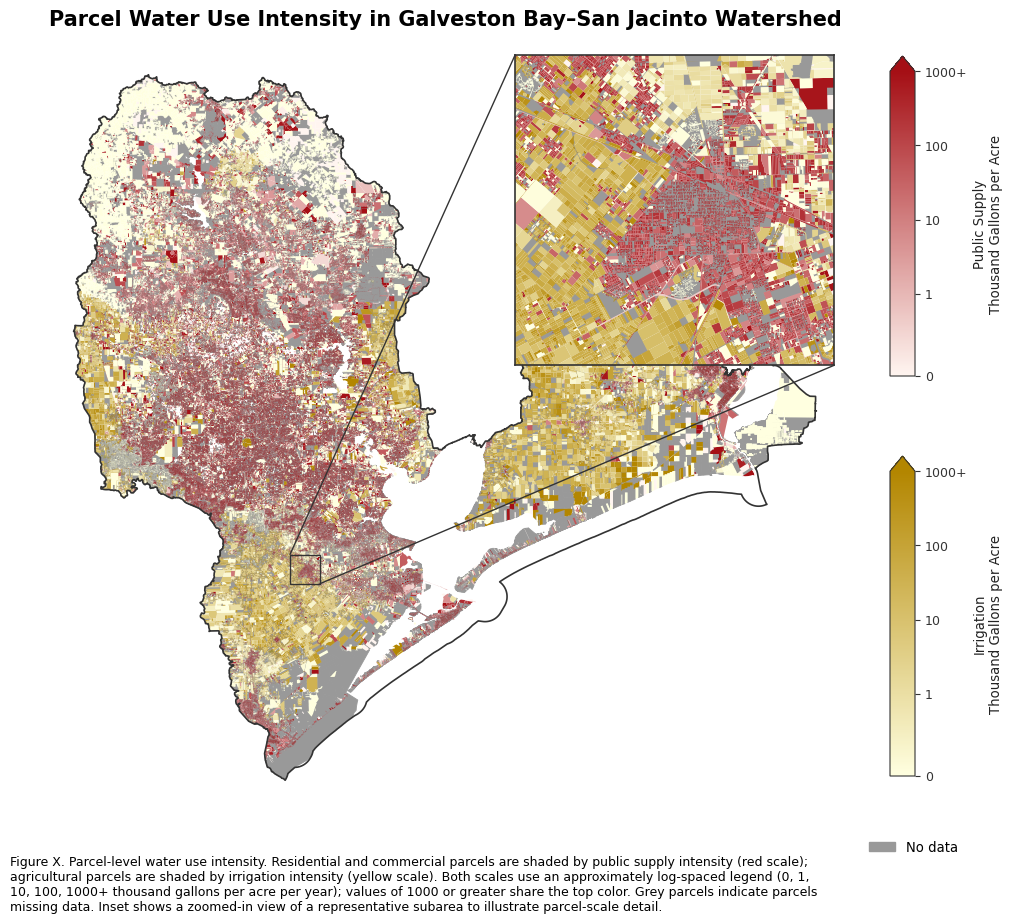

In [78]:
##### --------- MAP MILK PARCEL WATER USE INTENSITY ----------

# set figure to plot 
parcels = GBSJ_parcels.copy() # GBSJ_parcels, LCRR_parcels, MILK_parcels
basin = GBSJ_basin.copy() # GBSJ_basin, LCRR_basin, MILK_basin
watershed = 'Galveston Bay–San Jacinto' # Galveston Bay–San Jacinto, Lake Champlain–Richelieu River, or Milk River
watershed_code = 'GBSJ' #GBSJ, LCRR, or MILK

# set b_box 
# GBSJ = (-95.30603,29.38080,-95.21200,29.46013)
# LCRR = (-73.12375,44.45686,-73.03424,44.52832)
# MILK = (-109.78792,48.50831,-109.60905,48.61946)
bbox_wgs84 = box(-95.30603,29.38080,-95.21200,29.46013)

### ------ SET STYLE ----- 

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MISSING_COLOR = '#e6e6e6'
MISSING_EDGE = '#999999'

### ----- CLASSIFY PARCELS -----
is_res_com = parcels['parcel_type'].isin(['residential', 'commercial'])
is_ag = parcels['parcel_type'] == 'agricultural'

mask_supply = is_res_com & parcels['public_supply_kgal_per_year_per_acre_built_up'].notna()
mask_irrigation = is_ag & parcels['irrigation_kgal_per_year_per_acre_ag_land'].notna()
mask_missing = ~(mask_supply | mask_irrigation)  # covers missing parcel_type or missing relevant value

parcels_supply = parcels[mask_supply].copy()
parcels_irrigation = parcels[mask_irrigation].copy()
parcels_missing = parcels[mask_missing].copy()

# clip at 1000 so anything >=1000 shares the top color
parcels_supply['plot_val'] = parcels_supply['public_supply_kgal_per_year_per_acre_built_up'].clip(lower=0, upper=1000)
parcels_irrigation['plot_val'] = parcels_irrigation['irrigation_kgal_per_year_per_acre_ag_land'].clip(lower=0, upper=1000)

### ----- COLOR SCALES -----
# custom light->dark reds / yellows so they read distinctly from each other
reds_cmap = LinearSegmentedColormap.from_list('reds_seq', ['#fff5f0', '#a50f15'])
yellows_cmap = LinearSegmentedColormap.from_list('yellows_seq', ['#ffffe0', '#b38600'])

# symlog norm gives near-equal visual spacing across 0 | 1 | 10 | 100 | 1000
# (linthresh=1 makes the 0-1 segment behave like one log decade)
norm = SymLogNorm(linthresh=1, linscale=1, vmin=0, vmax=1000, base=10)

### ----- PLOT -----
fig, ax = plt.subplots(figsize=(10, 10))

### Plot parcels, by group
parcels_missing.plot(
    ax=ax, color=MISSING_EDGE, edgecolor=MISSING_EDGE,
    linewidth=0.6, zorder=1
)
parcels_supply.plot(
    ax=ax, column='plot_val', cmap=reds_cmap, norm=norm,
    edgecolor='none', linewidth=0, zorder=2
)
parcels_irrigation.plot(
    ax=ax, column='plot_val', cmap=yellows_cmap, norm=norm,
    edgecolor='none', linewidth=0, zorder=2
)

# basin outline, styled to match watershed outline in choropleth figure
basin.boundary.plot(ax=ax, color="#333333", linewidth=1.2, zorder=3)

ax.set_title(
    f"Parcel Water Use Intensity in {watershed} Watershed",
    fontsize=15, fontweight='bold', pad=10
)
ax.set_axis_off()

### Plot inset 

bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_wgs84], crs="EPSG:4326").to_crs(target_crs)
minx, miny, maxx, maxy = bbox_gdf.total_bounds

axins = inset_axes(
    ax,
    width="40%",   
    height="40%",
    loc="upper right",
    borderpad=1,
)

parcels_missing.plot(
    ax=axins, color=MISSING_EDGE, edgecolor=MISSING_EDGE,
    linewidth=0.8, zorder=1
)
parcels_supply.plot(
    ax=axins, column='plot_val', cmap=reds_cmap, norm=norm,
    edgecolor='none', linewidth=0, zorder=2
)
parcels_irrigation.plot(
    ax=axins, column='plot_val', cmap=yellows_cmap, norm=norm,
    edgecolor='none', linewidth=0, zorder=2
)

basin.boundary.plot(ax=axins, color="#333333", linewidth=1.2, zorder=3)

axins.set_xlim(minx, maxx)
axins.set_ylim(miny, maxy)
axins.set_xticks([])
axins.set_yticks([])
for spine in axins.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("#333333")
    spine.set_linewidth(1.2)

rect, c1, c2 = mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="#333333", lw=1)
rect.set_clip_on(False)
c1.set_clip_on(False)
c2.set_clip_on(False)

rect.set_zorder(10)
c1.set_zorder(10)
c2.set_zorder(10)

### ----- LEGENDS (two colorbars, symlog ticks, arrow indicating 1000+) -----

tick_vals = [0, 1, 10, 100, 1000]
tick_labels = ['0', '1', '10', '100', '1000+']

cax_supply = fig.add_axes([0.90, 0.55, 0.025, 0.32])
sm_supply = ScalarMappable(norm=norm, cmap=reds_cmap)
sm_supply.set_array([])
cb_supply = fig.colorbar(sm_supply, cax=cax_supply, extend='max')
cb_supply.set_ticks(tick_vals)
cb_supply.set_ticklabels(tick_labels)
cb_supply.set_label('Public Supply\nThousand Gallons per Acre', fontsize=9.5)
cb_supply.ax.tick_params(labelsize=9)

cax_irrigation = fig.add_axes([0.90, 0.15, 0.025, 0.32])
sm_irrigation = ScalarMappable(norm=norm, cmap=yellows_cmap)
sm_irrigation.set_array([])
cb_irrigation = fig.colorbar(sm_irrigation, cax=cax_irrigation, extend='max')
cb_irrigation.set_ticks(tick_vals)
cb_irrigation.set_ticklabels(tick_labels)
cb_irrigation.set_label('Irrigation\nThousand Gallons per Acre', fontsize=9.5)
cb_irrigation.ax.tick_params(labelsize=9)

### ----- NO DATA LEGEND -----

no_data_patch = Patch(facecolor=MISSING_EDGE, edgecolor=MISSING_EDGE, label='No data')
fig.legend(
    handles=[no_data_patch],
    loc='lower right',
    bbox_to_anchor=(0.98, 0.06),
    frameon=False,
    fontsize=9.5,
)

### ----- CAPTION -----
caption_text = (
    "Figure X. Parcel-level water use intensity. Residential and commercial parcels are shaded by public supply intensity (red scale);\n" 
    "agricultural parcels are shaded by irrigation intensity (yellow scale). Both scales use an approximately log-spaced legend (0, 1,\n" 
    "10, 100, 1000+ thousand gallons per acre per year); values of 1000 or greater share the top color. Grey parcels indicate parcels \n"
    "missing data. Inset shows a zoomed-in view of a representative subarea to illustrate parcel-scale detail."
)
fig.text(0.02, 0.012, caption_text, ha='left', va='bottom', fontsize=9, wrap=True)
fig.tight_layout(rect=[0.03, 0.06, 0.88, 0.95])

plt.savefig(out_dir / f"{watershed_code}_parcel_water_intensity_map.png", dpi=300, bbox_inches="tight")
plt.show()